In [77]:

import os
import yaml
from copy import deepcopy
from functools import partial
from pprint import pprint
from typing import Optional,Literal

import numpy as np
import pandas as pd
import pyreadr as pyr

import matplotlib.pyplot as plt
import seaborn as sns

import optuna

from sklearn.model_selection import cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import make_scorer, r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, BaggingRegressor
from xgboost import XGBRegressor

from IPython.display import clear_output

# Cross-Validation and Optuna 
The goal of Optuna is to find the set of hyperparameters that gives the best model performance. Normally you create an \textit{Objective function}, that is a value you want to minimise or maximise while searching for a range of given hyperparameters. Optuna search algorithm will find the combinantion of hyperparameters that suit your objective function. Optuna offers also multi-objective search, and as defult uses “Non-Dominated Sorting Genetic Algorithm II” (NSGA-II) that is It’s a genetic algorithm designed for multi-objective optimisation. We suggest to read this article to understand more (https://www.geeksforgeeks.org/deep-learning/non-dominated-sorting-genetic-algorithm-2-nsga-ii/). 

To stabilize Hyperparameters results we also do cross-validation, when deciding the number of folds we thought that 5 was too little, while, 10 folds give to little validation tests. 8 folds was a good in-between

In our case we decided to dare and find the hyper parameters that minimize the following:

To evaluate how good each hyperparameter trial is, we do not simply train the model once — instead, we use cross-validation to obtain a more reliable estimate of the model’s performance.

In [78]:

train:pd.DataFrame = pyr.read_r('datasets/train.rds')[None]
rs_seed=1
prof_qmd = False

In [79]:
def ParamXGB(trial):
    '''
    Hyperparameters Search Method for Optuna - XGB model
    '''
    params = {
        "Model__n_estimators": trial.suggest_int("Model__n_estimators", 400, 1200, step=10),
        "Model__learning_rate": trial.suggest_float("Model__learning_rate", 0.01, 0.2, step=0.002),
        "Model__max_depth": trial.suggest_int("Model__max_depth", 2, 8),
        "Model__subsample": trial.suggest_float("Model__subsample", 0.5, 1.0),
        "Model__colsample_bytree": trial.suggest_float("Model__colsample_bytree", 0.5, 1.0),
        "Model__reg_lambda": trial.suggest_float("Model__reg_lambda", 1e-3, 10, log=True),# log-scaled
        "Model__reg_alpha": trial.suggest_float("Model__reg_alpha", 1e-3, 10, log=True),# log-scaled
        "Model__min_child_weight": trial.suggest_int("Model__min_child_weight", 2, 8),
        "Model__gamma": trial.suggest_float("Model__gamma", 0.0, 5.0),
        "Model__grow_policy": trial.suggest_categorical("Model__grow_policy", ["lossguide", "depthwise"]),
    }
    return params



def ParamRF(trial):
    '''
    Hyperparameters Search Method for Optuna - Random Forest model
    '''
    params = {
        "Model__n_estimators": trial.suggest_int("Model__n_estimators", 200, 1200, step=20),
        "Model__max_depth": trial.suggest_categorical(
            "Model__max_depth", [None] + list(range(3, 9))
        ),
        "Model__min_samples_split": trial.suggest_int("Model__min_samples_split", 2, 20),
        "Model__min_samples_leaf": trial.suggest_int("Model__min_samples_leaf", 8, 15),
        "Model__max_features": trial.suggest_categorical("Model__max_features", ["sqrt", 0.3, 1.0]),
        "Model__max_leaf_nodes": trial.suggest_categorical(
            "Model__max_leaf_nodes", [None] + list(range(40, 201, 5))
        ),
        "Model__min_impurity_decrease": trial.suggest_float(
            "Model__min_impurity_decrease", 0.0, 1e-8
        ),
        "Model__ccp_alpha": trial.suggest_float("Model__ccp_alpha", 0.0, 0.02),
    }

    return params


def ParamDTR(trial):
    '''
    Hyperparameters Search Method for Optuna - Decision Tree Regressor model
    '''
    params = {
        "Model__criterion": trial.suggest_categorical(
            "Model__criterion", ["squared_error", "friedman_mse"]
        ),
        "Model__max_depth": trial.suggest_int("Model__max_depth", 6, 25),
        "Model__min_samples_split": trial.suggest_int("Model__min_samples_split", 5, 25),
        "Model__min_samples_leaf": trial.suggest_int("Model__min_samples_leaf", 5, 18),
        "Model__max_features": trial.suggest_categorical(
            "Model__max_features", ["sqrt", 0.3, 0.5, 0.7, 1.0]
        ),
        "Model__ccp_alpha": trial.suggest_float("Model__ccp_alpha", 0.0, 0.05),
        "Model__min_impurity_decrease": trial.suggest_float("Model__min_impurity_decrease", 0.0, 0.01),
    }
    return params

def ParamADA(trial):
    '''
    Hyperparameters Search Method for Optuna - Decision Tree Regressor model w/ADA boost
    '''
    params = {
        "Model__n_estimators": trial.suggest_int("Model__n_estimators", 100, 1200, step=10),
        "Model__learning_rate": trial.suggest_float("Model__learning_rate", 1e-4, 1.0, log=True),
        "Model__loss": trial.suggest_categorical("Model__loss", ['linear', 'square', 'exponential'])
    }
    return params

def ParamBAG(trial):
    """
    Hyperparameters Search Method for Optuna - Bagging Regressor with Decision Tree base estimator
    """
    bootstrap = trial.suggest_categorical("Model__bootstrap", [True, False])

    params = {
        "Model__n_estimators": trial.suggest_int("Model__n_estimators", 50, 1200, step=10),
        "Model__max_samples": trial.suggest_float("Model__max_samples", 0.6, 1.0),
        "Model__max_features": trial.suggest_float("Model__max_features", 0.5, 1.0),
        "Model__bootstrap": bootstrap,
        "Model__bootstrap_features": trial.suggest_categorical("Model__bootstrap_features", [False, True])
    }

    if bootstrap:
        params["Model__oob_score"] = trial.suggest_categorical("Model__oob_score", [False, True])
    else:
        params["Model__oob_score"] = False
    return params



In [ ]:
class YMLstudy():
    '''
    Homemade Class for to save studies as YML file.
    Display and save Optuna Studies in the folder optuna-study. It creates one if does not exist
    Parameters
    ----------
    model [str]: name of model you are working on

    Returns
    ----------
    None
    '''
    
    def __init__(self, model:str):

        os.makedirs("optuna-study", exist_ok=True)

        self.model = model
        self.file_name = f'{model}-opt_parm.yml'
        self.location = f'optuna-study/{self.file_name}'
        
        if os.path.isfile(self.location):
            self._get_vals()
    
    def read(self, what:Optional[str] = None):

            if what in ['all', None]:
                return self.best_all 
            else:
                return self.best_all[what]


    def write_study(self, study: optuna.Study):
        """
        Save only best_trials to YAML file
        or the efficient frontier in case of multi-optim
        """
        with open(self.location, "w") as writer:
            pareto_data = []
            for t in study.best_trials:
                pareto_data.append({
                    "trial_number": t.number,
                    "values": [round(v, 4) for v in (
                        t.values if isinstance(t.values, (list, tuple)) else [t.value]
                    )],
                    "params": t.params,
                })

            yaml.safe_dump(
                {"best_trials": pareto_data},
                writer,
                default_flow_style=False,
                sort_keys=False,
            )

        self._get_vals()


    def _get_vals(self):
        """
        Load the first best trial from YAML (for quick access).
        the best values will be those in the parato frontier that
        gives the minimum.
        """
        with open(self.location, "r") as loader:
            out = yaml.safe_load(loader)
            self.best_all = out

            best_trials = out.get("best_trials", [])

            if not best_trials:
                self.best_idx = None
                self.best_parameters = None
                self.results = None
                return None

            best_trial = min(best_trials, key=lambda t: 
                0.7*t["values"][0]+0.3*t["values"][1])

            self.best_idx = best_trial["trial_number"]
            self.best_parameters = best_trial["params"]
            self.results = best_trial["values"]
            self.results_sum = sum(best_trial["values"])


def Search(model:Literal['RF', 'DTR', 'XGB', 'ADA', 'BAG'],
           df:pd.DataFrame,
           scores = {
                "RMSE": make_scorer(root_mean_squared_error, greater_is_better=False),
            },
            directions:list[str] = ['minimize'],
            scale:bool=False,
            minimize_gap:bool = True,
            trials:int=1000,
            rs_seed:int=1) -> optuna.study.Study:
            """
            It does Optuna hyperparameter search with preprocessing and cross-validation.
            I added multi-objective tuning, In our case minimize RMSE and GAP. 

            Optional Scaler, optional scaling. Uses YMLstudy to save best trials

            Parameters
            ----------
            model : str
                Model name ('RF', 'DTR', 'ADA','BAG','XGB').
            df : pd.DataFrame
                Input data with features and target column 'score'.
            scores : dict, optional
                Custom scikit-learn scoring dictionary (default: RMSE).
            directions : list[str], optional
                Optimization direction(s). Default: ['minimize'].
            scale : bool, default=False
                Whether to scale numeric features.
            minimize_gap : bool, default=True
                If True, adds a second objective to minimize train–test RMSE gap.
            trials : int, default=1000
                Number of Optuna trials.
            rs_seed : int, default=1

            Returns
            -------
            study : optuna.study.Study
                The completed Optuna study object.
            """
            ml_model,parameters = _modelSelection(model)

            X = deepcopy(df.drop(columns=["score"]))
            y = deepcopy(df["score"])

            cats = X.select_dtypes(include=["object", "category"]).columns.tolist()
            nums = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

            preprocessor = ColumnTransformer([
                ("categorical", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cats),
                ("numeric", StandardScaler() if scale else "passthrough", nums)
            ])

            pipeline = Pipeline([
                ("preprocessor", preprocessor),
                ("Model", ml_model)
            ])
            ### I need to fix X
            yml = YMLstudy(model)

            study = optuna.create_study(
                    study_name=f"{model}_score",
                    storage="sqlite:///optuna-study/optuna-study.db",
                    directions=directions+(['minimize'] if minimize_gap else []), # multi-objective
                    load_if_exists=True
                )
            objF = partial(OptunaObj,
                        data = (X,y),
                        pipe = pipeline,
                        scores=scores,
                        param=parameters,
                        min_gap = minimize_gap)
            
            study.optimize(objF, n_trials=trials)

            clear_output()

            yml.write_study(study)

            return study

def OptunaObj(
        trial,
        data:tuple,
        pipe:Pipeline,
        scores:dict,
        min_gap:bool,
        param,
        rs_seed:int=1):
    
    '''
    Objective Function for Optuna -> find the hyper parameters that minimize the return
    '''
    
    x,y=data
    print(scores)
    pipe.set_params(**param(trial))

    res = cross_validate(
        estimator=pipe,
        X=x,
        y=y,
        cv=KFold(n_splits=8, shuffle=True, random_state=rs_seed),
        scoring=scores,
        n_jobs=-1,
        verbose=0,
        return_train_score=min_gap
    )
    rmse_fix = -res["test_RMSE"]
    rmse, rmse_std = np.mean(rmse_fix), np.std(rmse_fix) #becase cross_validate
    if min_gap:
        gaps = abs((-res["train_RMSE"])-rmse_fix)
        mean_gap, std_gap = np.mean(gaps), np.std(gaps)
        return rmse+0.5*rmse_std, mean_gap+0.5*std_gap
    else:
        return rmse


def _modelSelection(model):

    dtr_param = {'Model__criterion': 'friedman_mse',
        'Model__max_depth': 15,
        'Model__min_samples_split': 18,
        'Model__min_samples_leaf': 6,
        'Model__max_features': 0.5,
        'Model__ccp_alpha': 0.015509288515925103,
        'Model__min_impurity_decrease': 0.004465450147343869}

    match model:

        case 'RF':
            ml_model = RandomForestRegressor(bootstrap=True,
                            criterion='squared_error',
                            random_state=rs_seed)
            parameters = ParamRF
        case 'DTR':
            ml_model = DecisionTreeRegressor(splitter="best",
                            max_leaf_nodes=None,
                            random_state=rs_seed)
            parameters = ParamDTR

        case 'XGB':
            ml_model = XGBRegressor(random_state=rs_seed)
            parameters = ParamXGB

        case 'ADA':
            ''' Optim pre existing model'''
            if not prof_qmd:
                dtr_param = YMLstudy('DTR').best_parameters

            clean_dtr_par = {k.removeprefix('Model__'):v for k,v in dtr_param.items()}

            dtr_model = DecisionTreeRegressor(
                            splitter="best",
                            max_leaf_nodes=None,
                            random_state=rs_seed
                            ).set_params(**clean_dtr_par)
            ml_model = AdaBoostRegressor(dtr_model,random_state=rs_seed)
            parameters = ParamADA

        case 'BAG':
            if not prof_qmd:
                dtr_param = YMLstudy('DTR').best_parameters

            clean_dtr_par = {k.removeprefix('Model__'):v for k,v in dtr_param.items()}

            dtr_model = DecisionTreeRegressor(
                            splitter="best",
                            max_leaf_nodes=None,
                            random_state=rs_seed
                            ).set_params(**clean_dtr_par)
            ml_model = BaggingRegressor(dtr_model,random_state=rs_seed)
            parameters = ParamBAG


    return ml_model,parameters


def TestModel(
        model:str,
        study_param:dict,
        df:pd.DataFrame,
        scale:bool=False,
        scores:dict = {
                "RMSE": make_scorer(root_mean_squared_error, greater_is_better=False),
                "MSE": make_scorer(mean_squared_error, greater_is_better=False),
                "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
                "R2": make_scorer(r2_score, greater_is_better=True),

            },
        cross_val:bool = True,
        k_splits:int = 5):

    print(f'\n\nUsing best parameter from optuna study for the {model} model: ')
    pprint(study_param)

    ml_model,_ = _modelSelection(model)

    X = deepcopy(df.drop(columns=["score"]))
    y = deepcopy(df["score"])

    cats = X.select_dtypes(include=["object", "category"]).columns.tolist()
    nums = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

    preprocessor = ColumnTransformer([
        ("categorical", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cats),
        ("numeric", StandardScaler() if scale else "passthrough", nums)
    ])

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("Model", ml_model)
    ]).set_params(**study_param)

    if cross_val:
        cv = cross_validate(
            estimator=pipeline,
            X=X,
            y=y,
            cv=KFold(n_splits=k_splits, shuffle=True, random_state=rs_seed),
            scoring=scores,
            n_jobs=-1,
            verbose=0,
            return_train_score=True
        )

        train_rmse = -cv["train_RMSE"]
        test_rmse = -cv["test_RMSE"]
        gap = abs(train_rmse - test_rmse)


        output = pd.DataFrame(cv).abs().assign(
            model = model,
            gap = gap)
        
        return output
    else:
        model = pipeline.fit(X,y)

        return model
    

def cv_boxplot(concatenated: pd.DataFrame):
    """
    Creates 6 minimalist boxplots (3 models [test_RMSE, test_R2])
    with numeric y-axis labels only on the leftmost column.
    """

    metrics = ["test_RMSE", "test_R2", 'gap',]
    models = concatenated["model"].unique()
    fig, axes = plt.subplots(len(metrics), len(models), figsize=(10, 9), sharey="row")

    for row, metric in enumerate(metrics):
        for col, model in enumerate(models):
            ax = axes[row, col]
            data = concatenated.loc[concatenated["model"] == model, metric]

            # --- Boxplot ---
            ax.boxplot(
                data,
                vert=True,
                widths=0.35,
                patch_artist=True,
                boxprops=dict(facecolor="0.9", color="black", linewidth=0.9),
                medianprops=dict(color="black", linewidth=1.3),
                whiskerprops=dict(color="black", linewidth=0.9),
                capprops=dict(color="black", linewidth=0.9),
                flierprops=dict(marker=".", markersize=4, color="black", alpha=0.5),
            )

            # --- Mean marker only ---
            mean_val = np.mean(data)
            ax.plot(1, mean_val, "o", color="black", markersize=5)

            # --- Spines and ticks ---
            for spine in ["top", "right"]:
                ax.spines[spine].set_visible(False)
            ax.spines["bottom"].set_linewidth(0.8)
            ax.spines["left"].set_visible(col == 0)
            ax.spines["left"].set_linewidth(0.8 if col == 0 else 0)

            # X-axis cleanup
            ax.tick_params(axis="x", bottom=False, labelbottom=False)

            # Y-axis only on leftmost column
            if col == 0:
                ax.tick_params(axis="y", labelsize=8, width=0.6)
                ax.set_ylabel(metric.replace("_", " "), fontsize=9, labelpad=8)
            else:
                ax.tick_params(axis="y", left=False, labelleft=False)

            ax.set_title(model, fontsize=9, pad=3)

    plt.suptitle("Cross-Validation RMSE and R2 per Model", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()
    if not prof_qmd:
        plt.savefig('charts/CV_bbox.png')

def plot_gap_rmse(df: pd.DataFrame):
    plt.figure(figsize=(6,5))
    sns.scatterplot(
        data=df,
        x="gap", y="test_RMSE",
        hue="model", s=70, alpha=0.8,
        edgecolor="black", linewidth=0.6
    )

    plt.title("Stability vs Accuracy: Gap vs Test RMSE", fontsize=11)
    plt.xlabel("|Train–Test| RMSE Gap")
    plt.ylabel("Test RMSE")
    plt.legend(frameon=False)
    sns.despine()
    plt.tight_layout()
    if not prof_qmd:
        plt.savefig('charts/gap_accuracy_test.png')
    plt.show()


def plot_overfitting(concatenated: pd.DataFrame):
    plt.figure(figsize=(6,5))
    sns.scatterplot(
        data=concatenated,
        x="train_RMSE", y="test_RMSE",
        hue="model", style="model",
        s=70, alpha=0.8, edgecolor="black", linewidth=0.6
    )

    l = concatenated[["train_RMSE","test_RMSE"]].min().min()
    m = concatenated[["train_RMSE","test_RMSE"]].max().max()
    plt.plot([l, m], [l, m], 'k--', lw=1, label="Perfect Generalization") # train==test

    plt.title("Bias–Variance Check: Train vs Test RMSE (8-fold CV)", fontsize=11)
    plt.xlabel("Train RMSE")
    plt.ylabel("Test RMSE")
    plt.legend(frameon=False)
    sns.despine()
    plt.tight_layout()
    if not prof_qmd:
        plt.savefig('charts/overfitting.png')
    plt.show()


def cv_sum_bars(summ_table: pd.DataFrame):
    metrics = ["test_RMSE", 'test_MSE', 'test_MAE',"test_R2", "gap"]
    fig, axes = plt.subplots(1, len(metrics), figsize=(12, 4))

    for i, metric in enumerate(metrics):
        ax = axes[i]
        means = summ_table[f"mean_{metric}"]
        stds = summ_table[f"std_{metric}"]

        ax.bar(
            summ_table["model"],
            means,
            yerr=stds,
            capsize=4,
            color="0.8",
            edgecolor="black",
            linewidth=0.9
        )
        # ax.set_ylim(bottom=-0.05)
        ax.set_title(metric.replace("_", " "), fontsize=10, pad=5)


    plt.suptitle("Cross-Validation Mean w/ Std per Model", fontsize=11)
    plt.tight_layout()
    if not prof_qmd:
        plt.savefig('charts/cv_bars.png')
    plt.show()


# Optuna


In [ ]:
if not prof_qmd:
    xgb=Search('XGB',train,trials=1)
    dtr=Search('DTR',train,trials=1)
    rf=Search('RF',train,trials=1)
    ada=Search('ADA',train,trials=1)
    bag=Search('BAG',train,trials=2000)

    print("Best trial for XGB:", YMLstudy('XGB').best_parameters)
    print("Best trial for DTR:", YMLstudy('DTR').best_parameters)
    print("Best trial for RF: ", YMLstudy('RF').best_parameters)
    print("Best trial for ADA:", YMLstudy('ADA').best_parameters)
    print("Best trial for BAG:", YMLstudy('BAG').best_parameters)



if prof_qmd:
       
       xgb = {'Model__n_estimators': 740,
            'Model__learning_rate': 0.16,
            'Model__max_depth': 4,
            'Model__subsample': 0.555662543594597,
            'Model__colsample_bytree': 0.9815919085306092,
            'Model__reg_lambda': 0.0507566811158479,
            'Model__reg_alpha': 3.7839122777002308,
            'Model__min_child_weight': 2,
            'Model__gamma': 2.5266054240330855,
            'Model__grow_policy': 'lossguide'}
       
       dtr = {'Model__criterion': 'friedman_mse',
                'Model__max_depth': 15,
                'Model__min_samples_split': 18,
                'Model__min_samples_leaf': 6,
                'Model__max_features': 0.5,
                'Model__ccp_alpha': 0.015509288515925103,
                'Model__min_impurity_decrease': 0.004465450147343869}
       
       rf = {'Model__n_estimators': 340,
                'Model__max_depth': 6,
                'Model__min_samples_split': 4,
                'Model__min_samples_leaf': 9,
                'Model__max_features': 1.0,
                'Model__max_leaf_nodes': None,
                'Model__min_impurity_decrease': 3.5798749034080957e-09,
                'Model__ccp_alpha': 0.019534093354456262}

[I 2025-10-19 13:00:30,976] Using an existing study with name 'BAG_score' instead of creating a new one.


{'RMSE': make_scorer(root_mean_squared_error, greater_is_better=False, response_method='predict')}


[I 2025-10-19 13:00:31,789] Trial 13 finished with values: [0.9610414810361395, 0.21492833914692666] and parameters: {'Model__bootstrap': True, 'Model__n_estimators': 410, 'Model__max_samples': 0.7502544700472629, 'Model__max_features': 0.5124187382768812, 'Model__bootstrap_features': False, 'Model__oob_score': True}.


{'RMSE': make_scorer(root_mean_squared_error, greater_is_better=False, response_method='predict')}


[I 2025-10-19 13:00:33,636] Trial 14 finished with values: [0.9485896201889236, 0.21894354940391636] and parameters: {'Model__bootstrap': True, 'Model__n_estimators': 1010, 'Model__max_samples': 0.6889532795041131, 'Model__max_features': 0.963428903101385, 'Model__bootstrap_features': True, 'Model__oob_score': True}.


...

[I 2025-10-19 13:14:34,786] Trial 1165 finished with values: [0.9261463971393354, 0.22722100331176992] and parameters: {'Model__bootstrap': False, 'Model__n_estimators': 650, 'Model__max_samples': 0.7578352676984765, 'Model__max_features': 0.9439406219242765, 'Model__bootstrap_features': False}.
[I 2025-10-19 13:14:34,986] Trial 1166 finished with values: [0.94819744743297, 0.20538906062052004] and parameters: {'Model__bootstrap': False, 'Model__n_estimators': 60, 'Model__max_samples': 0.9520711590135268, 'Model__max_features': 0.6029765236254473, 'Model__bootstrap_features': True}.


{'RMSE': make_scorer(root_mean_squared_error, greater_is_better=False, response_method='predict')}
{'RMSE': make_scorer(root_mean_squared_error, greater_is_better=False, response_method='predict')}


[I 2025-10-19 13:14:35,184] Trial 1167 finished with values: [0.9275632820834177, 0.2244900785042226] and parameters: {'Model__bootstrap': False, 'Model__n_estimators': 60, 'Model__max_samples': 0.7362095178046839, 'Model__max_features': 0.9943547101223772, 'Model__bootstrap_features': False}.


{'RMSE': make_scorer(root_mean_squared_error, greater_is_better=False, response_method='predict')}


[I 2025-10-19 13:14:36,769] Trial 1168 finished with values: [0.9484467114692954, 0.22108316648772836] and parameters: {'Model__bootstrap': True, 'Model__n_estimators': 860, 'Model__max_samples': 0.9128146418635553, 'Model__max_features': 0.8740767774638314, 'Model__bootstrap_features': True, 'Model__oob_score': False}.


In [ ]:
k = 8
xgb_fin = TestModel('XGB',
          study_param = xgb if prof_qmd else YMLstudy('XGB').best_parameters,
          df=train,
          k_splits=k)

dtr_fin = TestModel('DTR',
          study_param = dtr if prof_qmd else YMLstudy('DTR').best_parameters,
          df=train,
          k_splits=k)

rf_fin = TestModel('RF',
          study_param = rf if prof_qmd else YMLstudy('RF').best_parameters,
          df=train,
          k_splits=k)

ada_fin = TestModel('ADA',
          study_param = ada if prof_qmd else YMLstudy('ADA').best_parameters,
          df=train,
          k_splits=k)

bag_fin = TestModel('BAG',
          study_param = bag if prof_qmd else YMLstudy('BAG').best_parameters,
          df=train,
          k_splits=k)

concatenated = pd.concat([xgb_fin,rf_fin,dtr_fin,ada_fin,bag_fin],axis=0).reset_index(drop=True)





Using best parameter from optuna study:
{'Model__colsample_bytree': 0.9815919085306092,
 'Model__gamma': 2.5266054240330855,
 'Model__grow_policy': 'lossguide',
 'Model__learning_rate': 0.16,
 'Model__max_depth': 4,
 'Model__min_child_weight': 5,
 'Model__n_estimators': 740,
 'Model__reg_alpha': 3.7839122777002308,
 'Model__reg_lambda': 0.24481085805808236,
 'Model__subsample': 0.5552997171468768}


Using best parameter from optuna study:
{'Model__ccp_alpha': 0.019465532586941975,
 'Model__criterion': 'friedman_mse',
 'Model__max_depth': 9,
 'Model__max_features': 0.5,
 'Model__min_impurity_decrease': 0.008663363461552305,
 'Model__min_samples_leaf': 6,
 'Model__min_samples_split': 18}


Using best parameter from optuna study:
{'Model__ccp_alpha': 0.018485648158400047,
 'Model__max_depth': 3,
 'Model__max_features': 1.0,
 'Model__max_leaf_nodes': 75,
 'Model__min_impurity_decrease': 6.6086975206585986e-09,
 'Model__min_samples_leaf': 8,
 'Model__min_samples_split': 10,
 'Model__n_est

In [ ]:
# get results
cols=[col for col in concatenated.columns if col not in ['fit_time','score_time','model']]
summ_table = (concatenated
         .pivot_table(index='model',
                      values=cols,
                      aggfunc=['mean', 'std'])
         .round(4))
summ_table.columns = [f"{s}_{m}" for s,m in summ_table.columns]

summ_table.reset_index(inplace=True)
if not prof_qmd:
    with pd.ExcelWriter('outputs/cv_results.xlsx') as w:
        summ_table.to_excel(w,sheet_name=f'k_{k}',index=False)

In [ ]:
mean_col = [col for col in summ_table.columns if col.startswith('mean')]
std_col  = [col for col in summ_table.columns if col.startswith('std')]

print('\nSummary of CV: MEAN\n')
display(summ_table[['model']+mean_col])

print('\nSummary of CV: STD\n')
display(summ_table[['model']+std_col])



Summary of CV: MEAN



,model,mean_gap,mean_test_MAE,mean_test_MSE,mean_test_R2,mean_test_RMSE,mean_train_MAE,mean_train_MSE,mean_train_R2,mean_train_RMSE
0,ADA,0.1862,0.6660,0.7444,0.2386,0.8465,0.5300,0.4672,0.5179,0.6833
1,DTR,0.0949,0.6659,0.7031,0.2465,0.8322,0.6431,0.6403,0.3400,0.7997
2,RF,0.1515,0.6643,0.7355,0.2378,0.8432,0.6169,0.6315,0.3484,0.7944
3,XGB,0.1342,0.6817,0.7545,0.2099,0.8584,0.5945,0.5722,0.4094,0.7563



Summary of CV: STD



,model,std_gap,std_test_MAE,std_test_MSE,std_test_R2,std_test_RMSE,std_train_MAE,std_train_MSE,std_train_R2,std_train_RMSE
0,ADA,0.1671,0.1440,0.3119,0.1394,0.1784,0.0147,0.0228,0.0152,0.0169
1,DTR,0.1002,0.1028,0.1906,0.1427,0.1101,0.0234,0.0477,0.0277,0.0301
2,RF,0.1119,0.1390,0.2915,0.1461,0.1674,0.0190,0.0364,0.0271,0.0233
3,XGB,0.1228,0.1190,0.2505,0.0883,0.1418,0.0139,0.0223,0.0167,0.0147


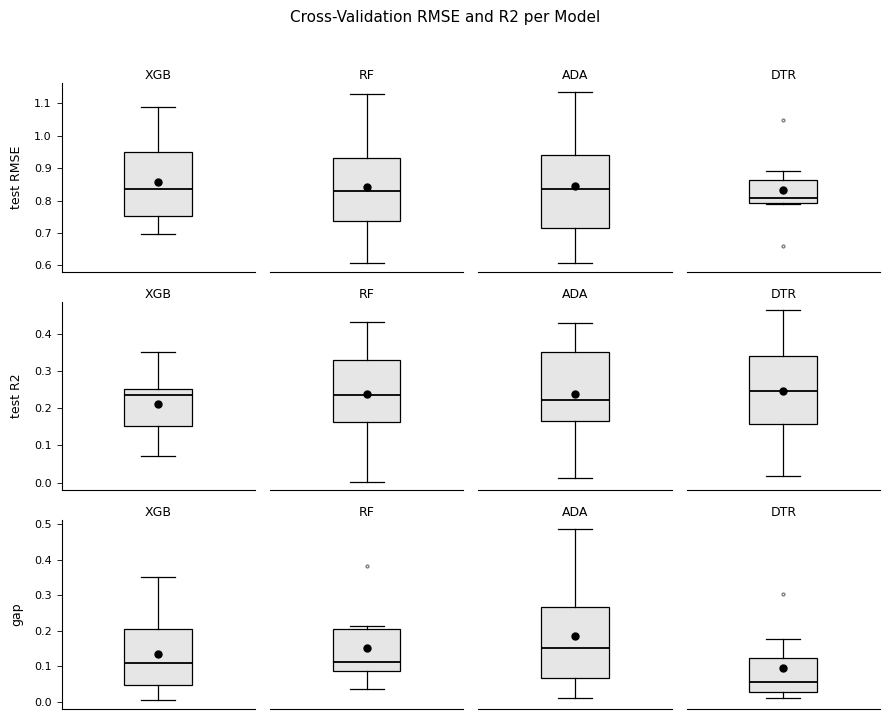

<Figure size 640x480 with 0 Axes>

In [ ]:
cv_boxplot(concatenated)

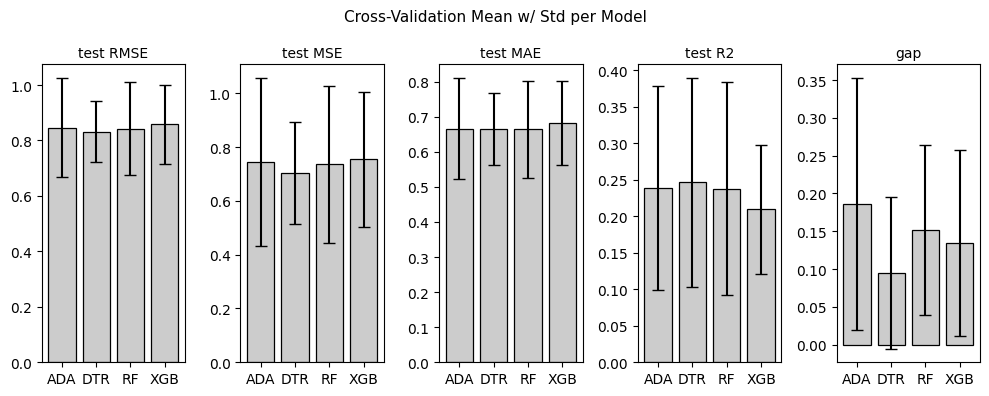

<Figure size 640x480 with 0 Axes>

In [ ]:
cv_sum_bars(summ_table)

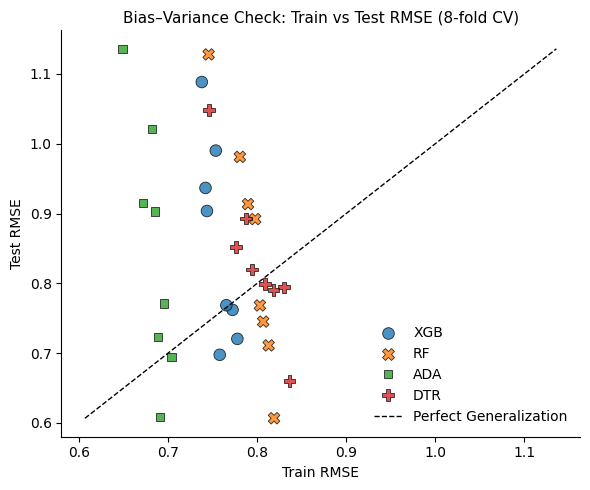

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_overfitting(concatenated)


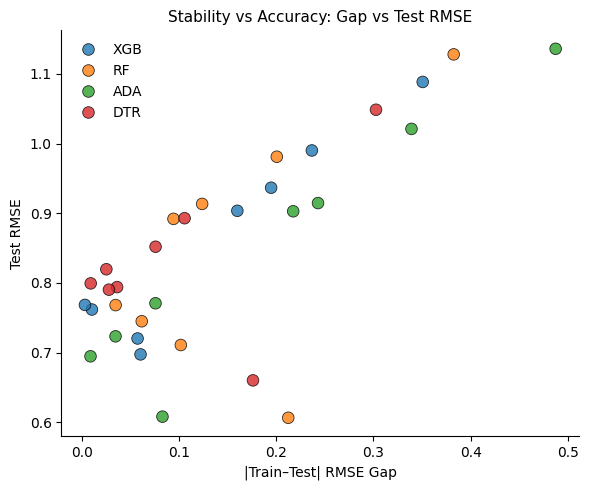

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_gap_rmse(concatenated)